In [1]:
#Parte 2 de la tarea

In [2]:
from pathlib import Path
import os

os.chdir(Path.cwd().parent)

In [3]:
import numpy as np
import pandas as pd
import random as random
import matplotlib.pyplot as plt
from src.funciones import media_muestral
from src.funciones import varianza_muestral

In [4]:
semilla = 223
rng = np.random.default_rng(semilla)

Tomando $\lambda = 100$ y $\mu=10$, tendremos que $\nu=\frac{\lambda}{\mu}=10$ <br>
Simulemos 1000 lanzamientos de la v.a. $Poiss(\nu)$

In [5]:
n=1000

rs_poisson= rng.poisson(lam=10,size=n)

Calculemos sus estimadores de media y varianza para cada valor de $n$

In [6]:
med_poiss= np.zeros(n)
for i in range(len(med_poiss)):
    med_poiss[i]= media_muestral(i, rs_poisson)

var_poiss= np.zeros(n)
for i in range(len(var_poiss)):
    var_poiss[i]= varianza_muestral(i, rs_poisson)


c:\Users\martin\Documents\U WEAS\DIM 2do semestre\Estadística\Tarea-1-estadistica\Tarea-1-estadistica\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\martin\Documents\U WEAS\DIM 2do semestre\Estadística\Tarea-1-estadistica\Tarea-1-estadistica\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\martin\Documents\U WEAS\DIM 2do semestre\Estadística\Tarea-1-estadistica\Tarea-1-estadistica\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:4270: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\martin\Documents\U WEAS\DIM 2do semestre\Estadística\Tarea-1-estadistica\Tarea-1-estadistica\.venv\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.tr

Los datos se pueden visualizar de la siguiente manera:

<positron-console-cell-7>:8: SyntaxWarning: invalid escape sequence '\o'
<positron-console-cell-7>:9: SyntaxWarning: invalid escape sequence '\o'


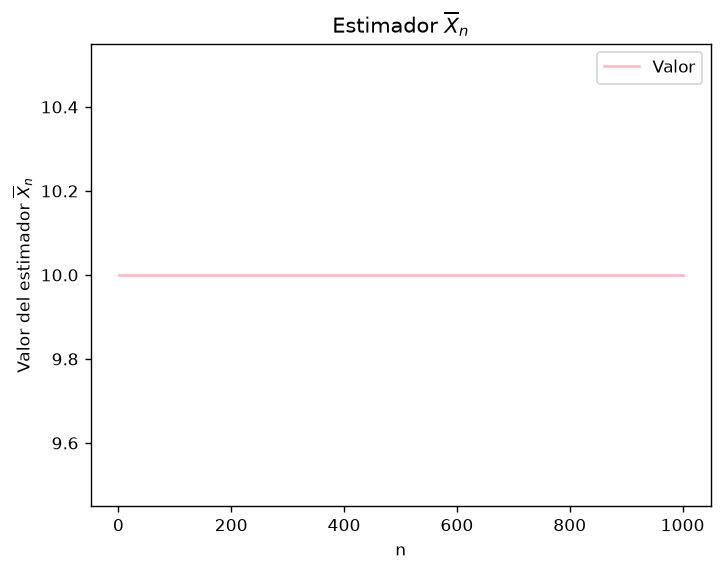

In [7]:
cantidad= np.arange(1, n +1)

nu= np.full(n,10)


plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor del estimador $\overline{X}_n$")
plt.title("Estimador $\overline{X}_n$")
plt.legend()
plt.savefig("results/estimador_media_muestral_poiss.png")
plt.show()

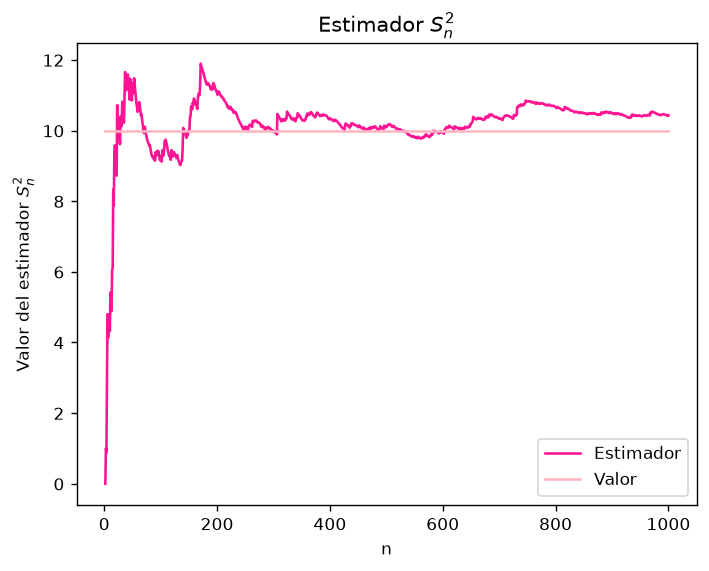

In [8]:
plt.plot(cantidad, var_poiss, color="deeppink",label="Estimador")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor del estimador $S_n^2$")
plt.title("Estimador $S_n^2$")
plt.legend()
plt.savefig("results/estimador_var_muestral_poiss.png")
plt.show()

Como ambos estiman el mismo parametro, $\nu$, los podemos comparar:

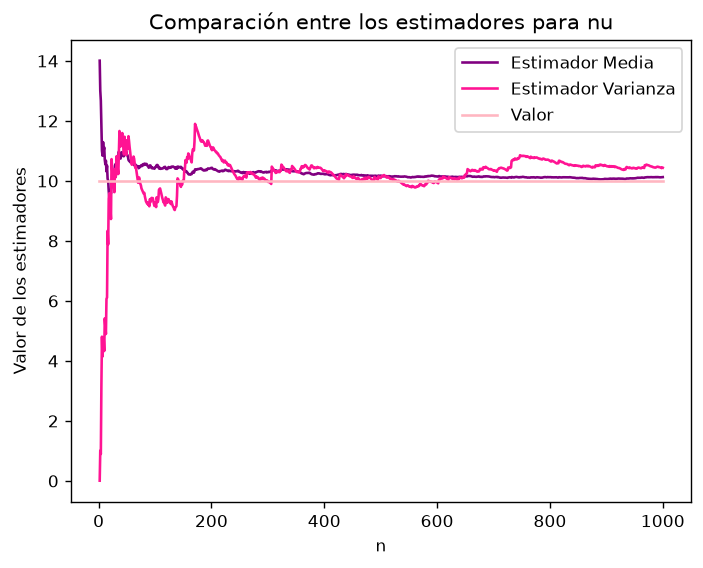

In [9]:
plt.plot(cantidad, med_poiss, color="purple",label="Estimador Media")
plt.plot(cantidad, var_poiss, color="deeppink",label="Estimador Varianza")
plt.plot(cantidad, nu, color="lightpink",label="Valor")
plt.xlabel("n")
plt.ylabel("Valor de los estimadores")
plt.title("Comparación entre los estimadores para nu")
plt.legend()
plt.savefig("results/comparacion_estimadores_poisson.png")
plt.show()

Para estimar la probabilidad del sistema vacío $\mathbb{P}(X=0)$ se proponen los siguientes estimadores: <br>
i) $\hat{g}_n^{(1)}=\exp(-\overline{X}_n)$, <br>
ii) $\hat{g}_n^{(2)}=\frac{1}{n} \sum_{i=1}^n\mathbf{1}_{X_i=0}$, <br>
iii) $\hat{g}_n^{(3)}=\exp(-S_n^2)$. <br>

In [10]:
g1 = np.exp(-med_poiss)

g2 = np.zeros(n)

for i in range(n):
    g2[i] = np.mean(rs_poisson[:i+1] == 0)

g3 = np.exp(-var_poiss)

valor_g_nu = np.full(n, np.exp(-10))

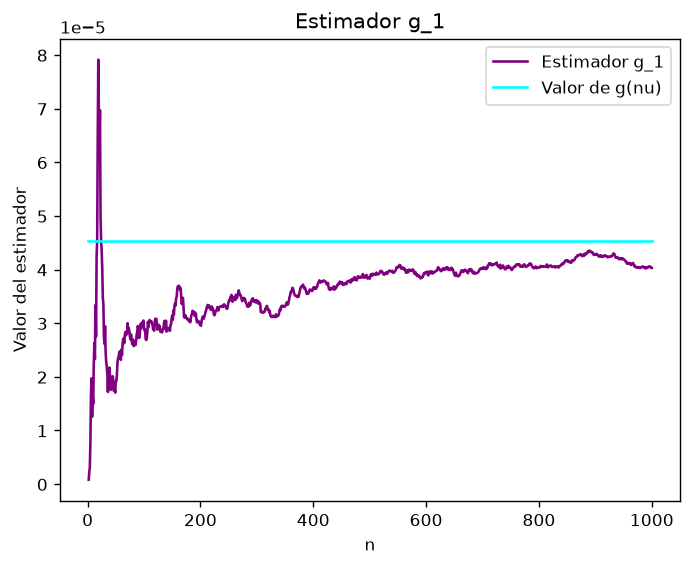

In [11]:
plt.plot(cantidad, g1, color="purple",label="Estimador g_1")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor del estimador")
plt.title("Estimador g_1")
plt.legend()
plt.savefig("results/estimador_g1.png")
plt.show()

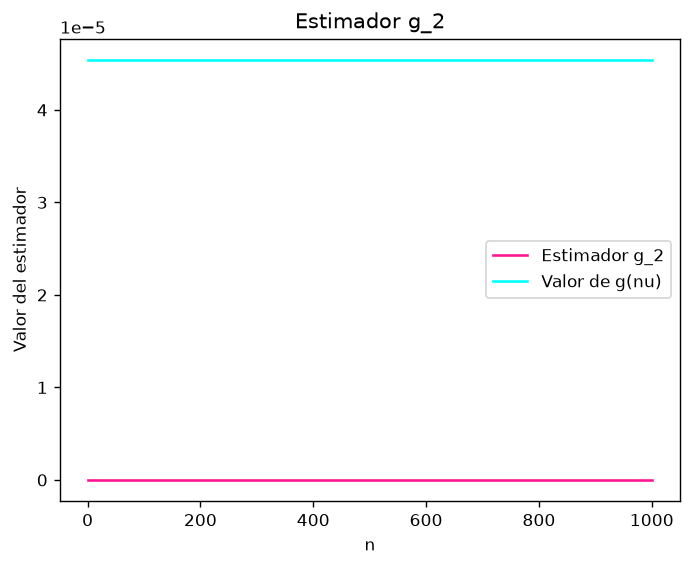

In [12]:
plt.plot(cantidad, g2, color="deeppink",label="Estimador g_2")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor del estimador")
plt.title("Estimador g_2")
plt.legend()
plt.savefig("results/estimador_g2.png")
plt.show()

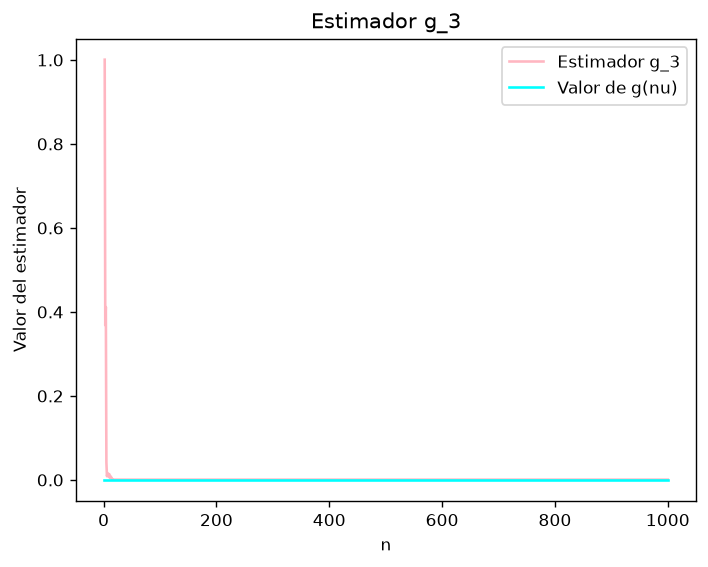

In [13]:
plt.plot(cantidad, g3, color="lightpink",label="Estimador g_3")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor del estimador")
plt.title("Estimador g_3")
plt.legend()
plt.savefig("results/estimador_g3.png")
plt.show()

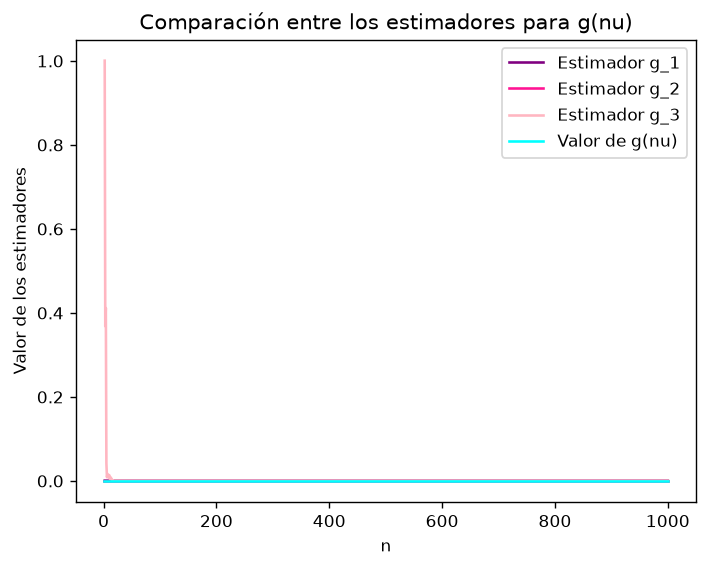

In [14]:
plt.plot(cantidad, g1, color="purple",label="Estimador g_1")
plt.plot(cantidad, g2, color="deeppink",label="Estimador g_2")
plt.plot(cantidad, g3, color="lightpink",label="Estimador g_3")
plt.plot(cantidad, valor_g_nu, color="cyan", label="Valor de g(nu)")
plt.xlabel("n")
plt.ylabel("Valor de los estimadores")
plt.title("Comparación entre los estimadores para g(nu)")
plt.legend()
plt.savefig("results/comparacion_estimadores_g(nu).png")
plt.show()

Ahora importemos el archivo datos_colas.csv y estudiemoslo para proponer un modelo parametrico:

In [15]:
df = pd.read_csv("data/raw/datos_cola.csv")

df["samples"].describe()

count    500.000000
mean       2.888000
std        1.642209
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        7.000000
Name: samples, dtype: float64

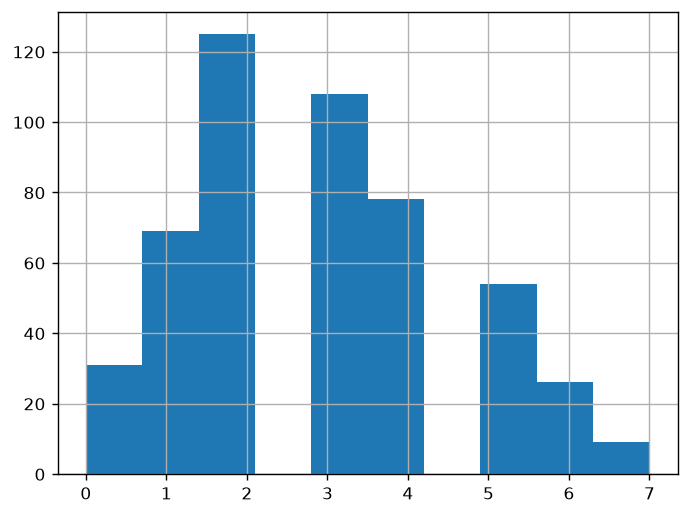

In [16]:
df["samples"].hist()
plt.show()

Sean $y_1,\dots,y_{500}$ los datos. Suponiendo $X_1, \dots, X_{500}$ una m.a.s. con $X_i(\omega)=x_i$ los datos se ven como las sumas parciales: la entrada 1 se ve como $x_1$, la entrada $i$-ésima se ve como $x_1+\dots +x_i$, etc.
Comparemos con distintas v.a. para ver que modelo parametrico proponer.